# Eksperiment 2: multiclass klasifikacija tipa defekta

Ovaj notebook dokumentuje kompletan tok Eksperimenta 2: formiranje skupa podataka, kontrolu vizuelnog curenja, izbor modela na validation skupu i jednokratnu evaluaciju izabranog modela na test skupu.

**Zadatak:** klasifikacija slike u jednu od pet klasa: `crack`, `abscission`, `leakage`, `corrosion` i `bulge`.

U eksperiment su uključene samo slike koje su u anotacijama imale tačno jednu vrstu defekta. Test skup nije korišćen za izbor modela ili hiperparametara.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULT_DIR = DATA_DIR / "results" / "experiment_2_multiclass"

METADATA_PATH = DATA_DIR / "metadata.csv"
VALIDATION_SUMMARY_PATH = RESULT_DIR / "validation_model_comparison.csv"
FINAL_RESULT_PATH = RESULT_DIR / "final_test_results.json"
REPORT_PATH = RESULT_DIR / "test_classification_report.csv"
CONFUSION_COUNTS_PATH = RESULT_DIR / "test_confusion_matrix_counts.csv"
CONFUSION_NORMALIZED_PATH = RESULT_DIR / "test_confusion_matrix_normalized.csv"
PREDICTIONS_PATH = RESULT_DIR / "test_predictions.csv"

required_paths = [
    METADATA_PATH,
    VALIDATION_SUMMARY_PATH,
    FINAL_RESULT_PATH,
    REPORT_PATH,
    CONFUSION_COUNTS_PATH,
    CONFUSION_NORMALIZED_PATH,
    PREDICTIONS_PATH,
]

missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"Nedostaju fajlovi: {missing_paths}")

print("Projektni direktorijum:", PROJECT_ROOT)
print("Svi potrebni rezultati postoje.")

Projektni direktorijum: /home/dareloq/Deep Neural Networks for Construction Defect Image Classification
Svi potrebni rezultati postoje.


## 1. Skup podataka i podela

Početni multiclass skup sadržao je 12.064 slike sa tačno jednom vrstom defekta. Vizuelno slične slike grupisane su perceptualnim hashom. Izabran je prag Hamming udaljenosti 6, a povezane slike su zadržane u istom splitu pomoću grupisane stratifikovane podele.

Pet vizuelnih grupa sadržalo je međusobno skoro identične slike sa različitim klasama. Uklonjeno je svih 127 dvosmislenih slika, pa finalni skup sadrži 11.937 slika u 2.159 vizuelnih grupa.

Ukupan broj slika: 11937
Broj vizuelnih grupa: 2159
Najveći broj splitova po vizuelnoj grupi: 1


,broj_slika
split,
train,9530
validation,1192
test,1215


split,train,validation,test
target_class,,,
abscission,2627,329,328
bulge,600,75,75
corrosion,1309,164,189
crack,3438,430,429
leakage,1556,194,194


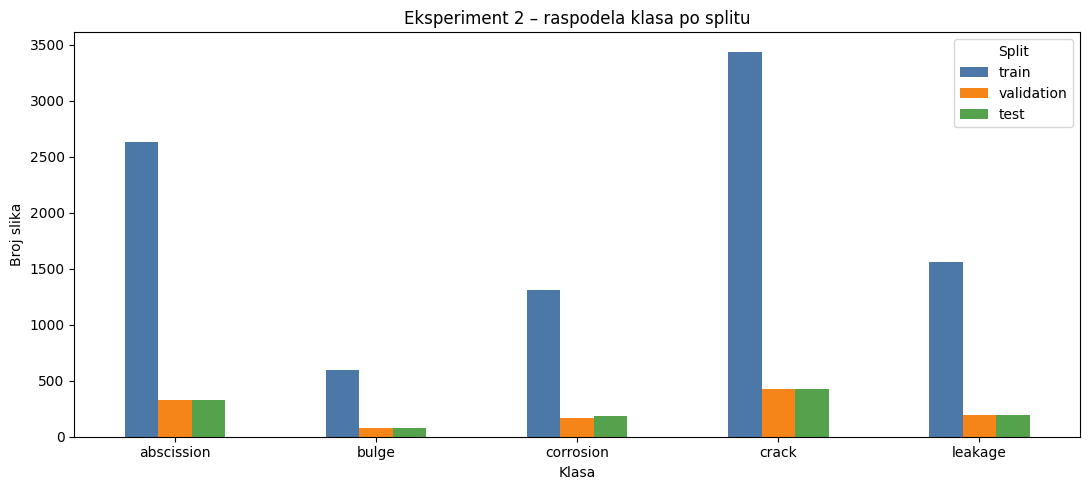

In [2]:
metadata = pd.read_csv(METADATA_PATH)

split_order = ["train", "validation", "test"]
class_order = ["abscission", "bulge", "corrosion", "crack", "leakage"]

split_counts = metadata["split"].value_counts().reindex(split_order)
class_split_counts = pd.crosstab(
    metadata["target_class"],
    metadata["split"],
).reindex(index=class_order, columns=split_order)

group_split_max = metadata.groupby("visual_group")["split"].nunique().max()

print("Ukupan broj slika:", len(metadata))
print("Broj vizuelnih grupa:", metadata["visual_group"].nunique())
print("Najveći broj splitova po vizuelnoj grupi:", group_split_max)
display(split_counts.rename("broj_slika").to_frame())
display(class_split_counts)

ax = class_split_counts.plot(
    kind="bar",
    figsize=(11, 5),
    color=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set_title("Eksperiment 2 – raspodela klasa po splitu")
ax.set_xlabel("Klasa")
ax.set_ylabel("Broj slika")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Split")
plt.tight_layout()
plt.savefig(RESULT_DIR / "dataset_split_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Kontrola vizuelnog curenja

Naivna podela je davala veoma visoku sličnost između train i validation slika. Nakon grupisanja sa pHash pragom 6, broj validation slika čiji je najbliži train sused imao kosinusnu sličnost najmanje 0,99 smanjen je sa 752 na 37. Broj parova sa sličnošću najmanje 0,999 smanjen je sa 78 na 0.

Ova promena objašnjava zašto su rezultati dobijeni na grupisanoj podeli realističniji od početnog rezultata na naivnoj podeli.

,split_metod,cosine_0.99_ili_vise,cosine_0.995_ili_vise,cosine_0.999_ili_vise
0,Naivni split,752,413,78
1,pHash prag 2,287,35,0
2,pHash prag 4,77,3,0
3,pHash prag 6,37,2,0


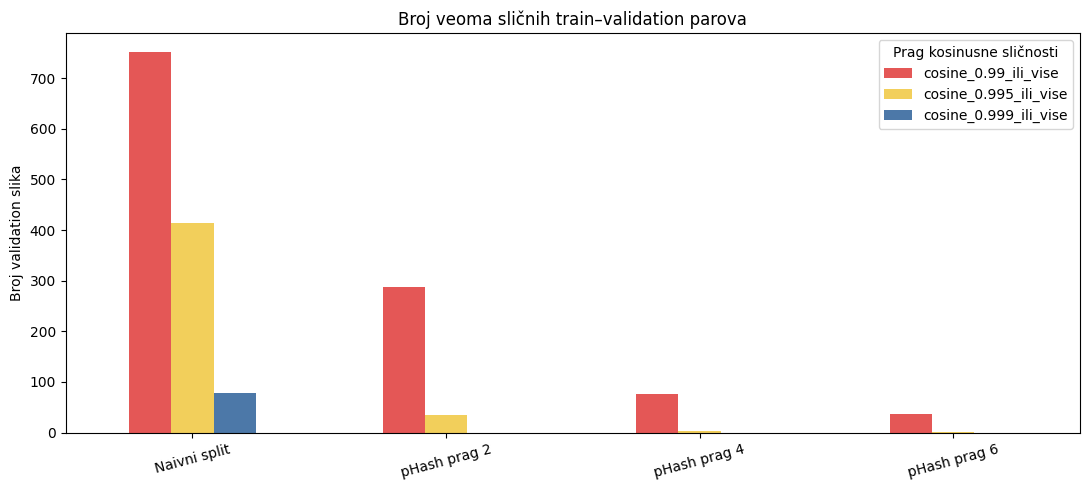

In [3]:
leakage_audit = pd.DataFrame(
    {
        "split_metod": ["Naivni split", "pHash prag 2", "pHash prag 4", "pHash prag 6"],
        "cosine_0.99_ili_vise": [752, 287, 77, 37],
        "cosine_0.995_ili_vise": [413, 35, 3, 2],
        "cosine_0.999_ili_vise": [78, 0, 0, 0],
    }
)
display(leakage_audit)

ax = leakage_audit.set_index("split_metod").plot(
    kind="bar",
    figsize=(11, 5),
    color=["#E45756", "#F2CF5B", "#4C78A8"],
)
ax.set_title("Broj veoma sličnih train–validation parova")
ax.set_xlabel("")
ax.set_ylabel("Broj validation slika")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Prag kosinusne sličnosti")
plt.tight_layout()
plt.savefig(RESULT_DIR / "visual_leakage_reduction.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Izbor modela na validation skupu

Poređene su tri unapred obučene CNN reprezentacije i tri klasična klasifikatora. Hiperparametri su birani isključivo prema validation macro F1 rezultatu.

,rank,feature_extractor,classifier,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,Inception-ResNet-v2,XGBoost,0.9648,0.9722,0.9737,0.9653
1,2,Inception-ResNet-v2,Logistic Regression,0.9589,0.9748,0.9728,0.9592
2,3,Inception-ResNet-v2,Random Forest,0.9539,0.9598,0.9643,0.9543
3,4,ResNet50,XGBoost,0.9513,0.9548,0.9599,0.9520
4,5,ResNet50,Logistic Regression,0.9471,0.9496,0.9557,0.9481
5,6,ConvNeXt V2 Tiny,XGBoost,0.9337,0.9435,0.9490,0.9341
6,7,ConvNeXt V2 Tiny,Logistic Regression,0.9119,0.9201,0.9288,0.9139
7,8,ResNet50,Random Forest,0.9169,0.9040,0.9193,0.9160
8,9,ConvNeXt V2 Tiny,Random Forest,0.9136,0.9002,0.9165,0.9131


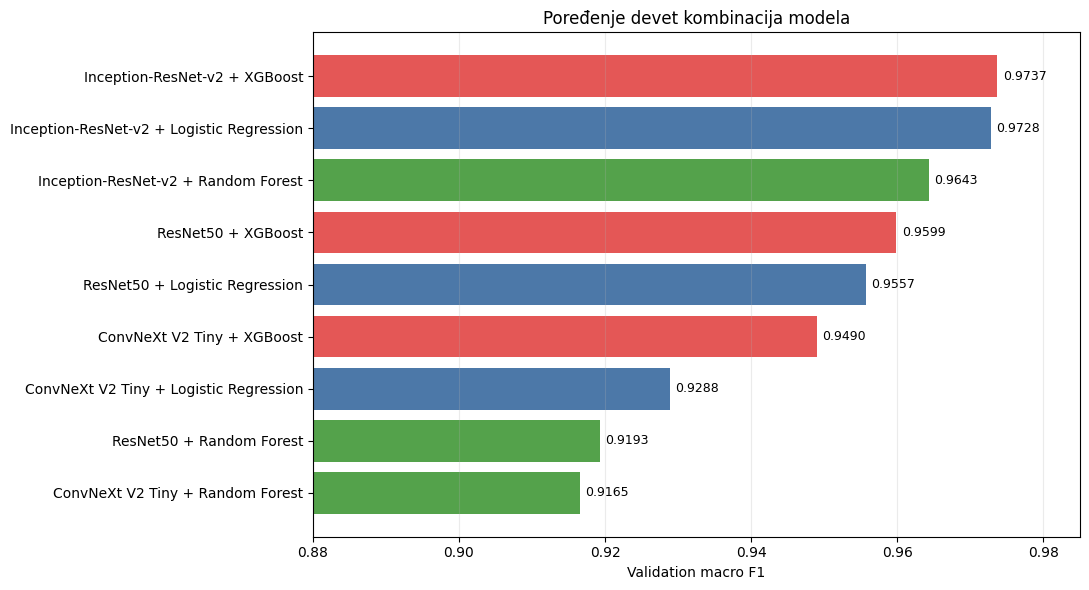

In [4]:
validation_summary = pd.read_csv(VALIDATION_SUMMARY_PATH).sort_values("rank")

display_columns = [
    "rank",
    "feature_extractor",
    "classifier",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
]

display(validation_summary[display_columns].round(4))

plot_data = validation_summary.sort_values("macro_f1", ascending=True).copy()
plot_data["model"] = plot_data["feature_extractor"] + " + " + plot_data["classifier"]

classifier_colors = {
    "Logistic Regression": "#4C78A8",
    "Random Forest": "#54A24B",
    "XGBoost": "#E45756",
}
colors = plot_data["classifier"].map(classifier_colors)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(plot_data["model"], plot_data["macro_f1"], color=colors)
ax.set_xlim(0.88, 0.985)
ax.set_xlabel("Validation macro F1")
ax.set_title("Poređenje devet kombinacija modela")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULT_DIR / "validation_macro_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

Najbolja validation konfiguracija bila je **Inception-ResNet-v2 + XGBoost** sa macro F1 rezultatom 0,9737. Logistička regresija nad istim feature-ima bila je veoma blizu sa 0,9728, dok je Random Forest ostvario 0,9643.

## 4. Konačna evaluacija na test skupu

Nakon izbora modela, XGBoost je ponovo treniran na spojenim train i validation podacima. Korišćeno je 239 stabala, `max_depth=4`, `learning_rate=0.1`, balansiranje klasa, `subsample=0.8` i `colsample_bytree=0.8`. Test skup je evaluiran jednom i nije korišćen za naknadno podešavanje.

Izabrani feature extractor: inception_resnet_v2
Izabrani klasifikator: xgboost
Train + validation: 10722
Test: 1215
Validation macro F1: 0.9737


,test
accuracy,0.7292
balanced_accuracy,0.7921
macro_f1,0.7823
weighted_f1,0.7350


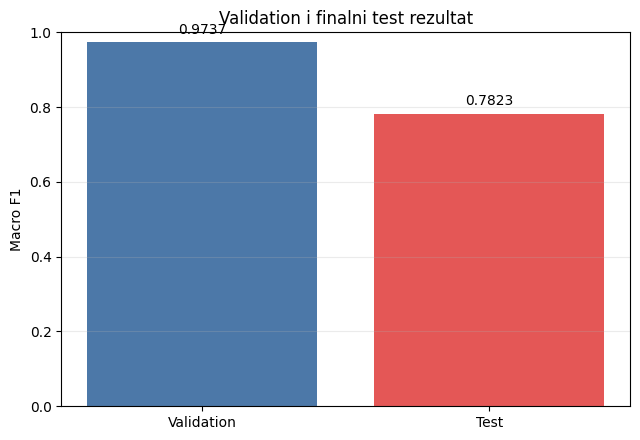

In [5]:
with FINAL_RESULT_PATH.open("r", encoding="utf-8") as file:
    final_result = json.load(file)

test_metrics = pd.Series(final_result["test_metrics"], name="test")
validation_macro_f1 = final_result["validation_macro_f1"]

print("Izabrani feature extractor:", final_result["feature_extractor"])
print("Izabrani klasifikator:", final_result["classifier"])
print("Train + validation:", final_result["sample_counts"]["train_plus_validation"])
print("Test:", final_result["sample_counts"]["test"])
print("Validation macro F1:", round(validation_macro_f1, 4))
display(test_metrics.round(4).to_frame())

metric_comparison = pd.DataFrame(
    {
        "skup": ["Validation", "Test"],
        "macro_f1": [validation_macro_f1, test_metrics["macro_f1"]],
    }
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(
    metric_comparison["skup"],
    metric_comparison["macro_f1"],
    color=["#4C78A8", "#E45756"],
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Macro F1")
ax.set_title("Validation i finalni test rezultat")
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULT_DIR / "validation_test_gap.png", dpi=180, bbox_inches="tight")
plt.show()

Test macro F1 iznosi **0,7823**, a accuracy **0,7292**. Pad u odnosu na validation rezultat iznosi približno 0,191 macro F1 poena. To pokazuje da finalni test sadrži vizuelne grupe koje se znatno teže generalizuju iz razvojnog skupa.

## 5. Rezultati po klasama

,precision,recall,f1-score,support
abscission,0.7714,0.6585,0.7105,328.0
bulge,1.0000,1.0000,1.0000,75.0
corrosion,0.9643,1.0000,0.9818,189.0
crack,0.7388,0.6527,0.6931,429.0
leakage,0.4421,0.6495,0.5261,194.0


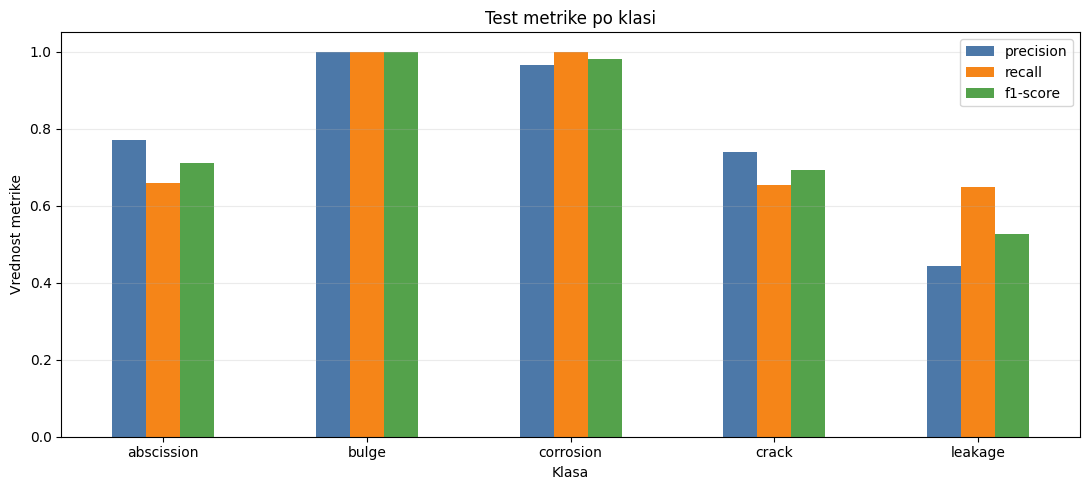

In [6]:
classification_report_table = pd.read_csv(REPORT_PATH, index_col=0)
per_class_report = classification_report_table.loc[class_order, [
    "precision", "recall", "f1-score", "support"
]]
display(per_class_report.round(4))

ax = per_class_report[["precision", "recall", "f1-score"]].plot(
    kind="bar",
    figsize=(11, 5),
    color=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set_ylim(0, 1.05)
ax.set_title("Test metrike po klasi")
ax.set_xlabel("Klasa")
ax.set_ylabel("Vrednost metrike")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULT_DIR / "test_per_class_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

`Bulge` i `corrosion` su prepoznati gotovo savršeno. Najslabiji rezultat ima `leakage` sa F1 rezultatom 0,5261. Klase `abscission` i `crack` imaju F1 rezultate 0,7105 i 0,6931.

## 6. Confusion matrica

,abscission,bulge,corrosion,crack,leakage
true_class,,,,,
abscission,216,0,3,98,11
bulge,0,75,0,0,0
corrosion,0,0,189,0,0
crack,0,0,1,280,148
leakage,64,0,3,1,126


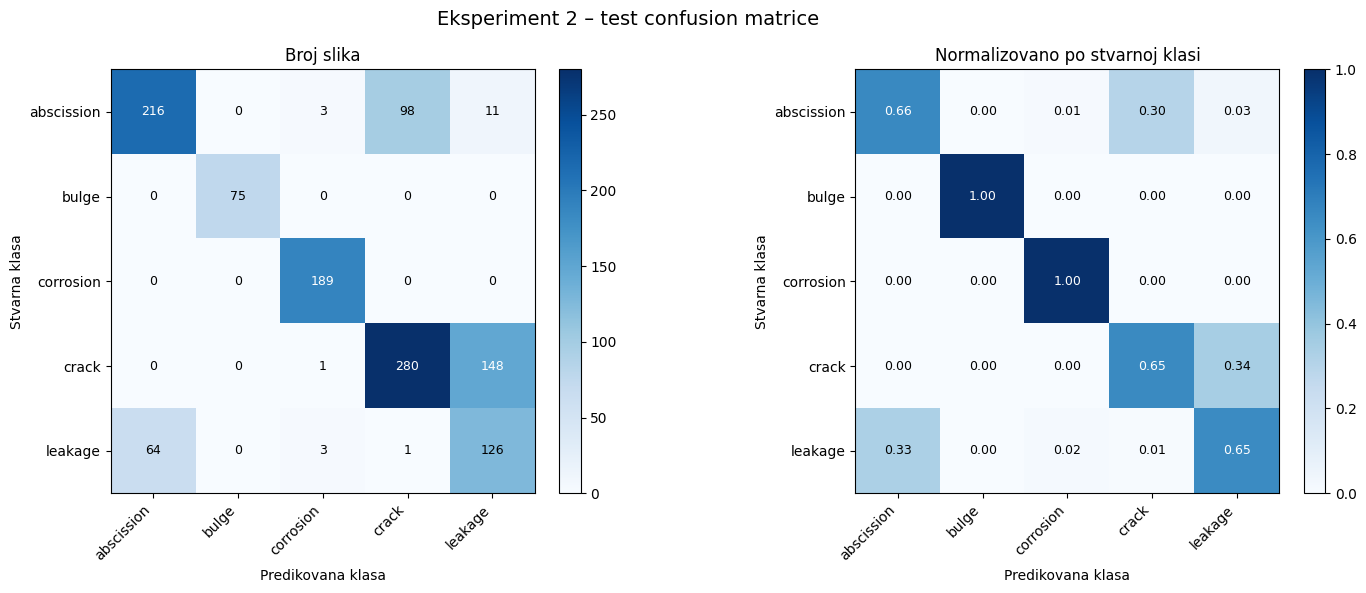

In [7]:
confusion_counts = pd.read_csv(CONFUSION_COUNTS_PATH, index_col=0)
confusion_normalized = pd.read_csv(CONFUSION_NORMALIZED_PATH, index_col=0)

display(confusion_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for axis, matrix, title, value_format in [
    (axes[0], confusion_counts, "Broj slika", "d"),
    (axes[1], confusion_normalized, "Normalizovano po stvarnoj klasi", ".2f"),
]:
    image = axis.imshow(matrix.to_numpy(), cmap="Blues", vmin=0)
    axis.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha="right")
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set_xlabel("Predikovana klasa")
    axis.set_ylabel("Stvarna klasa")
    axis.set_title(title)

    threshold = matrix.to_numpy().max() / 2
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix.iloc[row, column]
            text = format(int(value), value_format) if value_format == "d" else format(value, value_format)
            axis.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=9,
            )
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.suptitle("Eksperiment 2 – test confusion matrice", fontsize=14)
plt.tight_layout()
plt.savefig(RESULT_DIR / "test_confusion_matrix_notebook.png", dpi=180, bbox_inches="tight")
plt.show()

Dominantne greške su:

- 148 `crack` slika predviđeno je kao `leakage`;
- 98 `abscission` slika predviđeno je kao `crack`;
- 64 `leakage` slike predviđene su kao `abscission`.

Ove tri zamene čine najveći deo svih test grešaka.

## 7. Analiza grešaka i pouzdanosti

Broj tačnih predikcija: 886
Broj pogrešnih predikcija: 329


,true_class,predicted_class,broj_gresaka
0,crack,leakage,148
1,abscission,crack,98
2,leakage,abscission,64
3,abscission,leakage,11
4,leakage,corrosion,3
5,abscission,corrosion,3
6,crack,corrosion,1
7,leakage,crack,1


,count,mean,median,min,max
correct,,,,,
pogrešno,329,0.8707,0.9367,0.4212,0.9958
tačno,886,0.9545,0.9949,0.4570,1.0000


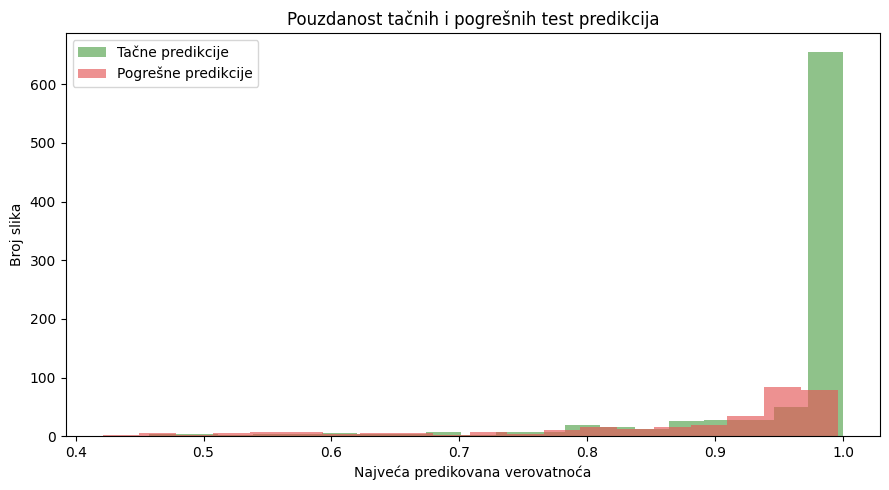

In [8]:
predictions = pd.read_csv(PREDICTIONS_PATH)
errors = predictions.loc[~predictions["correct"]].copy()

error_pairs = (
    errors.groupby(["true_class", "predicted_class"])
    .size()
    .rename("broj_gresaka")
    .sort_values(ascending=False)
    .reset_index()
)

confidence_summary = (
    predictions.groupby("correct")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={False: "pogrešno", True: "tačno"})
)

print("Broj tačnih predikcija:", int(predictions["correct"].sum()))
print("Broj pogrešnih predikcija:", len(errors))
display(error_pairs.head(10))
display(confidence_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    predictions.loc[predictions["correct"], "confidence"],
    bins=20,
    alpha=0.65,
    label="Tačne predikcije",
    color="#54A24B",
)
ax.hist(
    predictions.loc[~predictions["correct"], "confidence"],
    bins=20,
    alpha=0.65,
    label="Pogrešne predikcije",
    color="#E45756",
)
ax.set_xlabel("Najveća predikovana verovatnoća")
ax.set_ylabel("Broj slika")
ax.set_title("Pouzdanost tačnih i pogrešnih test predikcija")
ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "test_confidence_analysis.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Posebna analiza klase leakage

In [9]:
leakage_related = predictions.loc[
    (predictions["true_class"] == "leakage")
    | (predictions["predicted_class"] == "leakage")
].copy()

leakage_confusion = pd.crosstab(
    leakage_related["true_class"],
    leakage_related["predicted_class"],
)

high_confidence_leakage_errors = leakage_related.loc[
    ~leakage_related["correct"]
].sort_values("confidence", ascending=False)[
    ["image_id", "true_class", "predicted_class", "confidence"]
].head(20)

display(leakage_confusion)
print("Dvadeset najpouzdanijih grešaka povezanih sa klasom leakage:")
display(high_confidence_leakage_errors.round(4))

predicted_class,abscission,corrosion,crack,leakage
true_class,,,,
abscission,0,0,0,11
crack,0,0,0,148
leakage,64,3,1,126


Dvadeset najpouzdanijih grešaka povezanih sa klasom leakage:


,image_id,true_class,predicted_class,confidence
1131,Hefei8118,crack,leakage,0.9931
1133,Hefei8120,crack,leakage,0.9893
117,Hefei11005,leakage,abscission,0.9891
1132,Hefei8119,crack,leakage,0.9886
1130,Hefei8117,crack,leakage,0.9882
1129,Hefei8116,crack,leakage,0.9870
1115,Hefei8102,crack,leakage,0.9863
1126,Hefei8113,crack,leakage,0.9843
1127,Hefei8114,crack,leakage,0.9832
1047,Hefei8034,crack,leakage,0.9818


## 9. Zaključak

Eksperiment 2 je završen izborom modela **Inception-ResNet-v2 + XGBoost**. Model je na validation skupu ostvario macro F1 od 0,9737, dok je nakon finalnog treniranja na spojenom train i validation skupu na netaknutom test skupu ostvario:

- accuracy: **0,7292**;
- balanced accuracy: **0,7921**;
- macro F1: **0,7823**;
- weighted F1: **0,7350**.

Veliki pad između validation i test rezultata predstavlja glavni nalaz eksperimenta. Grupisana podela sprečava direktno deljenje veoma sličnih slika između skupova, ali pojedine test vizuelne sekvence i dalje predstavljaju drugačiju distribuciju scena. Najveći prostor za poboljšanje postoji kod razdvajanja klasa `crack`, `leakage` i `abscission`.

Test rezultat se smatra konačnim. Test skup se nakon ove evaluacije ne koristi za izbor novih hiperparametara ili retrospektivni izbor drugog modela.

## 10. Sačuvani artefakti

- `validation_model_comparison.csv` – svih devet validation kombinacija;
- `final_test_results.json` – finalne metrike i konfiguracija;
- `test_classification_report.csv` – rezultati po klasama;
- `test_confusion_matrix_counts.csv` i `test_confusion_matrix_normalized.csv`;
- `test_predictions.csv` – predikcija, pouzdanost i verovatnoće za svaku test sliku;
- `final_inception_resnet_v2_xgboost.json` – sačuvani finalni XGBoost model.

Svi navedeni fajlovi nalaze se u `data/results/experiment_2_multiclass/`.